# PHẦN 4: TRÍCH XUẤT ĐẶC TRƯNG (FEATURE ENGINEERING)

Notebook này thực hiện toàn bộ quá trình trích xuất đặc trưng gồm:
1. Lựa chọn và loại bỏ đặc trưng dựa trên phân tích tương quan
2. Chuẩn hóa dữ liệu (StandardScaler)
3. Giảm chiều dữ liệu (PCA - Principal Component Analysis)
4. Trích xuất đặc trưng thời gian (Sin/Cos Encoding)
5. Tạo đặc trưng trễ (Lag Features)

## 0. Import thư viện và Load dữ liệu

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load dữ liệu
train_df = pd.read_csv('clean_data/clean_data_train.csv')
#test_df  = pd.read_csv('clean_data/clean_data_test.csv')

# Parse datetime
train_df['time'] = pd.to_datetime(train_df['time'])
#test_df['time']  = pd.to_datetime(test_df['time'])

print(f"Train shape: {train_df.shape}")
# print(f"Test shape:  {test_df.shape}")
print(f"\nCác cột: {train_df.columns.tolist()}")

Train shape: (42573, 8)

Các cột: ['time', 'wind_speed_10m', 'temperature_2m', 'cloud_cover', 'relative_humidity_2m', 'surface_pressure', 'precipitation', 'vapour_pressure_deficit']


---
## 1. Lựa chọn và loại bỏ đặc trưng

Phân tích ma trận tương quan (Correlation Matrix) để đánh giá mức độ đóng góp thông tin của từng đặc trưng với biến mục tiêu `temperature_2m`, từ đó quyết định loại bỏ các biến gây ra hiện tượng rò rỉ dữ liệu (Data Leakage).

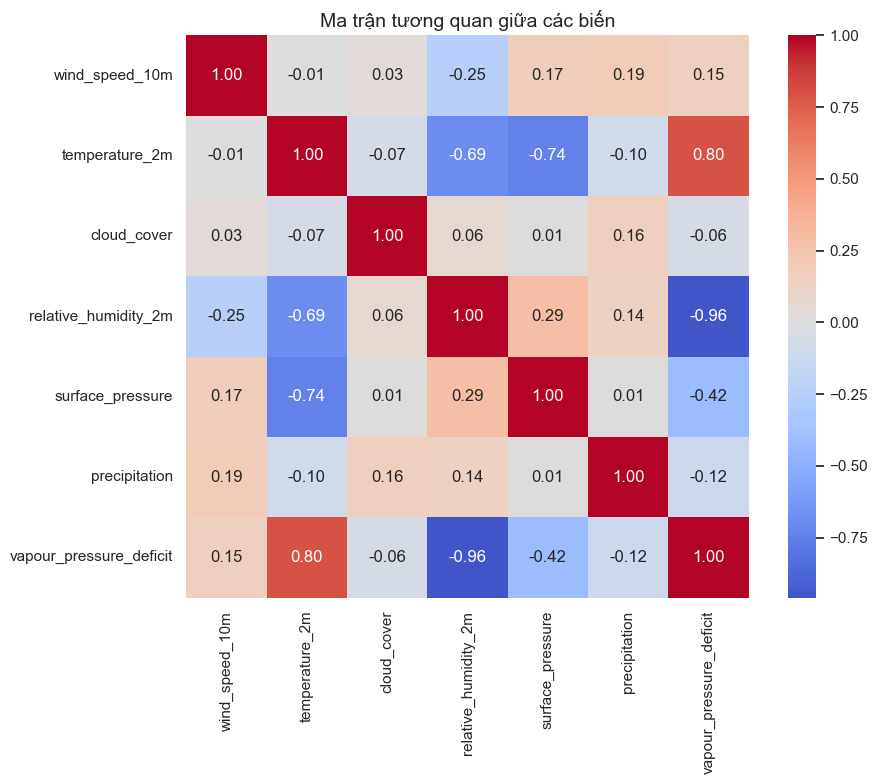


=== TƯƠNG QUAN VỚI temperature_2m ===
temperature_2m             1.000
vapour_pressure_deficit    0.796
wind_speed_10m            -0.009
cloud_cover               -0.070
precipitation             -0.095
relative_humidity_2m      -0.690
surface_pressure          -0.737
Name: temperature_2m, dtype: float64


In [4]:
# ==================================================
# 1.1 Phân tích ma trận tương quan
# ==================================================
numeric_cols = [col for col in train_df.columns if col != 'time']
corr_matrix = train_df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            ax=ax)
ax.set_title('Ma trận tương quan giữa các biến', fontsize=14)
plt.tight_layout()
plt.show()

print("\n=== TƯƠNG QUAN VỚI temperature_2m ===")
print(corr_matrix['temperature_2m'].sort_values(ascending=False).round(3))

---
## 2. Tạo đặc trưng trễ (Lag Features)

Dựa trên phân tích ACF/PACF và Lag Plots từ EDA, nhiệt độ có tính tự tương quan cao theo thời gian. Các lag features được chọn dựa trên ý nghĩa vật lý:
- **lag_1, lag_2, lag_3**: Quán tính nhiệt ngắn hạn
- **lag_12**: Nghịch đảo bức xạ ngày/đêm (12h trước)
- **lag_24**: Cùng khung giờ hôm qua (chu kỳ ngày)
- **lag_72**: 3 ngày trước (xu hướng ngắn hạn)
- **lag_168**: 1 tuần trước (chu kỳ tuần)

In [5]:
# ==================================================
# 2. TẠO LAG FEATURES (CHỈ XỬ LÝ TRÊN TẬP TRAIN)
# Đảm bảo chống rò rỉ dữ liệu tuyệt đối
# ==================================================

# Đảm bảo dữ liệu được sắp xếp chuẩn theo thời gian
train_df = train_df.sort_values('time').reset_index(drop=True)

# --------------------------------------------------
# 2.1 Tạo lag cho biến mục tiêu (Nhiệt độ)
# --------------------------------------------------
lag_hours = [1, 2, 3, 12, 24, 72, 168]
for lag in lag_hours:
    train_df[f'temp_lag_{lag}'] = train_df['temperature_2m'].shift(lag)

# --------------------------------------------------
# 2.2 Tạo lag 24h cho các biến ngoại sinh (CHUẨN BỊ CHO PCA)
# --------------------------------------------------
exogenous_cols = [
    'wind_speed_10m', 'cloud_cover', 'relative_humidity_2m', 
    'surface_pressure', 'precipitation', 'vapour_pressure_deficit'
]

lagged_exo_cols = []
for col in exogenous_cols:
    lag_col_name = f'{col}_lag_24'
    train_df[lag_col_name] = train_df[col].shift(24)
    lagged_exo_cols.append(lag_col_name)

# --------------------------------------------------
# 2.3 Loại bỏ dữ liệu khuyết thiếu (NaN) do shift
# --------------------------------------------------
# Vì lag lớn nhất là 168, ta sẽ mất 168 dòng đầu tiên của tập Train
train_df = train_df.dropna().reset_index(drop=True)

print("=== KẾT QUẢ LAG FEATURES TRÊN TẬP TRAIN ===")
print(f"Train shape: {train_df.shape}")
print(f"Các cột Target Lag: {[col for col in train_df.columns if 'temp_lag' in col]}")
print(f"Các cột Ngoại sinh Lag (Chuẩn bị fit PCA): \n{lagged_exo_cols}")
print(f"Train time range: {train_df['time'].min()} → {train_df['time'].max()}")

=== KẾT QUẢ LAG FEATURES TRÊN TẬP TRAIN ===
Train shape: (42405, 21)
Các cột Target Lag: ['temp_lag_1', 'temp_lag_2', 'temp_lag_3', 'temp_lag_12', 'temp_lag_24', 'temp_lag_72', 'temp_lag_168']
Các cột Ngoại sinh Lag (Chuẩn bị fit PCA): 
['wind_speed_10m_lag_24', 'cloud_cover_lag_24', 'relative_humidity_2m_lag_24', 'surface_pressure_lag_24', 'precipitation_lag_24', 'vapour_pressure_deficit_lag_24']
Train time range: 2021-01-08 00:00:00 → 2025-11-09 20:00:00


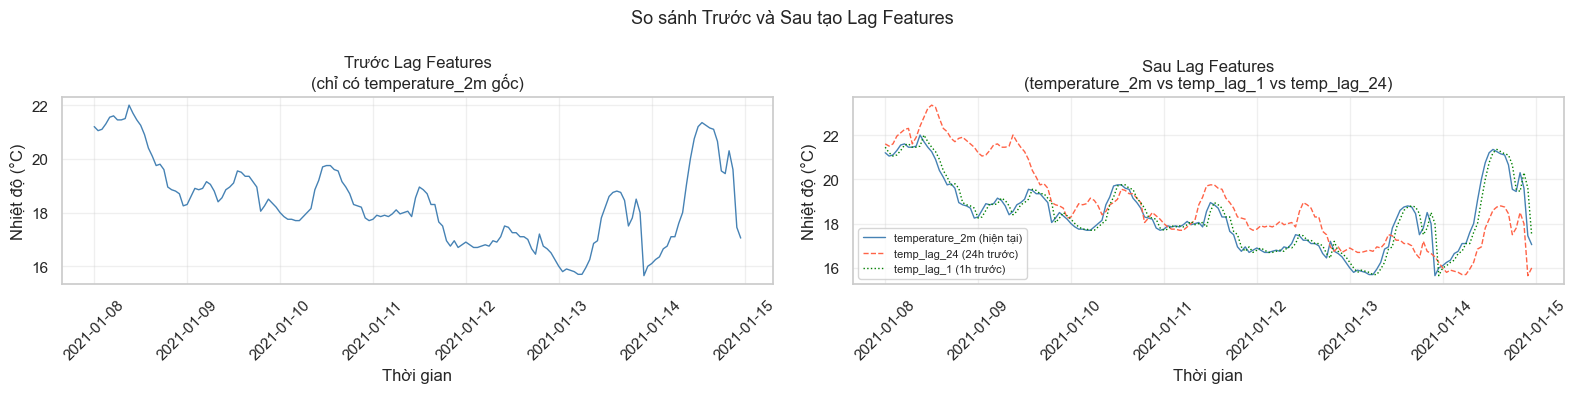

In [6]:
# ==================================================
# TRỰC QUAN HÓA: So sánh Trước và Sau tạo Lag Features
# ==================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Lấy 7 ngày đầu để visualize rõ
sample = train_df.iloc[:168]

# Trước lag — chỉ có temperature_2m gốc
axes[0].plot(sample['time'], sample['temperature_2m'],
             color='steelblue', linewidth=1)
axes[0].set_title('Trước Lag Features\n(chỉ có temperature_2m gốc)')
axes[0].set_xlabel('Thời gian')
axes[0].set_ylabel('Nhiệt độ (°C)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

# Sau lag — so sánh temp và lag_24
axes[1].plot(sample['time'], sample['temperature_2m'],
             color='steelblue', linewidth=1, label='temperature_2m (hiện tại)')
axes[1].plot(sample['time'], sample['temp_lag_24'],
             color='tomato', linewidth=1, linestyle='--', label='temp_lag_24 (24h trước)')
axes[1].plot(sample['time'], sample['temp_lag_1'],
             color='green', linewidth=1, linestyle=':', label='temp_lag_1 (1h trước)')
axes[1].set_title('Sau Lag Features\n(temperature_2m vs temp_lag_1 vs temp_lag_24)')
axes[1].set_xlabel('Thời gian')
axes[1].set_ylabel('Nhiệt độ (°C)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle('So sánh Trước và Sau tạo Lag Features', fontsize=13)
plt.tight_layout()
plt.show()


---
## 3. Phân tích thành phần chính (PCA)

Theo tài liệu bài giảng Chương 7 - Phân tích dữ liệu nhiều chiều, PCA sử dụng phép biến đổi trực giao để chuyển dữ liệu từ không gian nhiều chiều sang không gian mới ít chiều hơn, nhằm tối ưu hóa việc thể hiện sự biến thiên của dữ liệu.

**Quy trình PCA gồm các bước:**
1. Chuẩn hóa dữ liệu (StandardScaler)
2. Tính ma trận hiệp phương sai
3. Phân tích giá trị riêng (Explained Variance)
4. Phân tích Loading Matrix
5. Lựa chọn số chiều K và Transform

### 4.1 Chuẩn hóa dữ liệu (StandardScaler)

Chuẩn hóa Z-score là bước bắt buộc trước PCA vì PCA dựa trên phương sai — nếu không chuẩn hóa, biến có đơn vị lớn (như `surface_pressure` ~1009 hPa) sẽ chi phối toàn bộ kết quả PCA.

In [33]:
import os
import pickle
from sklearn.preprocessing import StandardScaler

# ==============================================================================
# 3.1 Chuẩn hóa dữ liệu (StandardScaler) cho PCA
# CHIẾN LƯỢC: Sử dụng dữ liệu NGOẠI SINH THỜI GIAN THỰC (Biết trước tương lai)
# ==============================================================================

# 1. Sử dụng trực tiếp danh sách cột ngoại sinh gốc tại thời điểm T
exogenous_cols = [
    'wind_speed_10m', 'cloud_cover', 'relative_humidity_2m',
    'surface_pressure', 'precipitation', 'vapour_pressure_deficit'
]

# 2. Lấy dữ liệu trực tiếp từ train_df (Không dùng shift 24h nữa)
X_train_exo = train_df[exogenous_cols].values

# 3. Khởi tạo và Chuẩn hóa
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_exo)

# 4. Lưu Scaler cho file Testing
os.makedirs('saved_models', exist_ok=True)
with open('saved_models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("=== KẾT QUẢ CHUẨN HÓA (NGOẠI SINH THỜI GIAN THỰC) ===")
print(f"X_train_scaled shape: {X_train_scaled.shape} (Đúng bằng số dòng tập Train x 6)")
print(f"\nTrước chuẩn hóa — Mean: {X_train_exo.mean(axis=0).round(3)}")
print(f"Trước chuẩn hóa — Std:  {X_train_exo.std(axis=0).round(3)}")
print(f"\nSau chuẩn hóa  — Mean: {X_train_scaled.mean(axis=0).round(4)}")
print(f"Sau chuẩn hóa  — Std:  {X_train_scaled.std(axis=0).round(4)}")

=== KẾT QUẢ CHUẨN HÓA (NGOẠI SINH THỜI GIAN THỰC) ===
X_train_scaled shape: (42405, 6) (Đúng bằng số dòng tập Train x 6)

Trước chuẩn hóa — Mean: [1.030800e+01 7.459800e+01 8.186800e+01 1.008999e+03 2.760000e-01
 7.050000e-01]
Trước chuẩn hóa — Std:  [ 6.513 34.073 11.715  5.372  1.099  0.643]

Sau chuẩn hóa  — Mean: [ 0.  0.  0.  0. -0. -0.]
Sau chuẩn hóa  — Std:  [1. 1. 1. 1. 1. 1.]


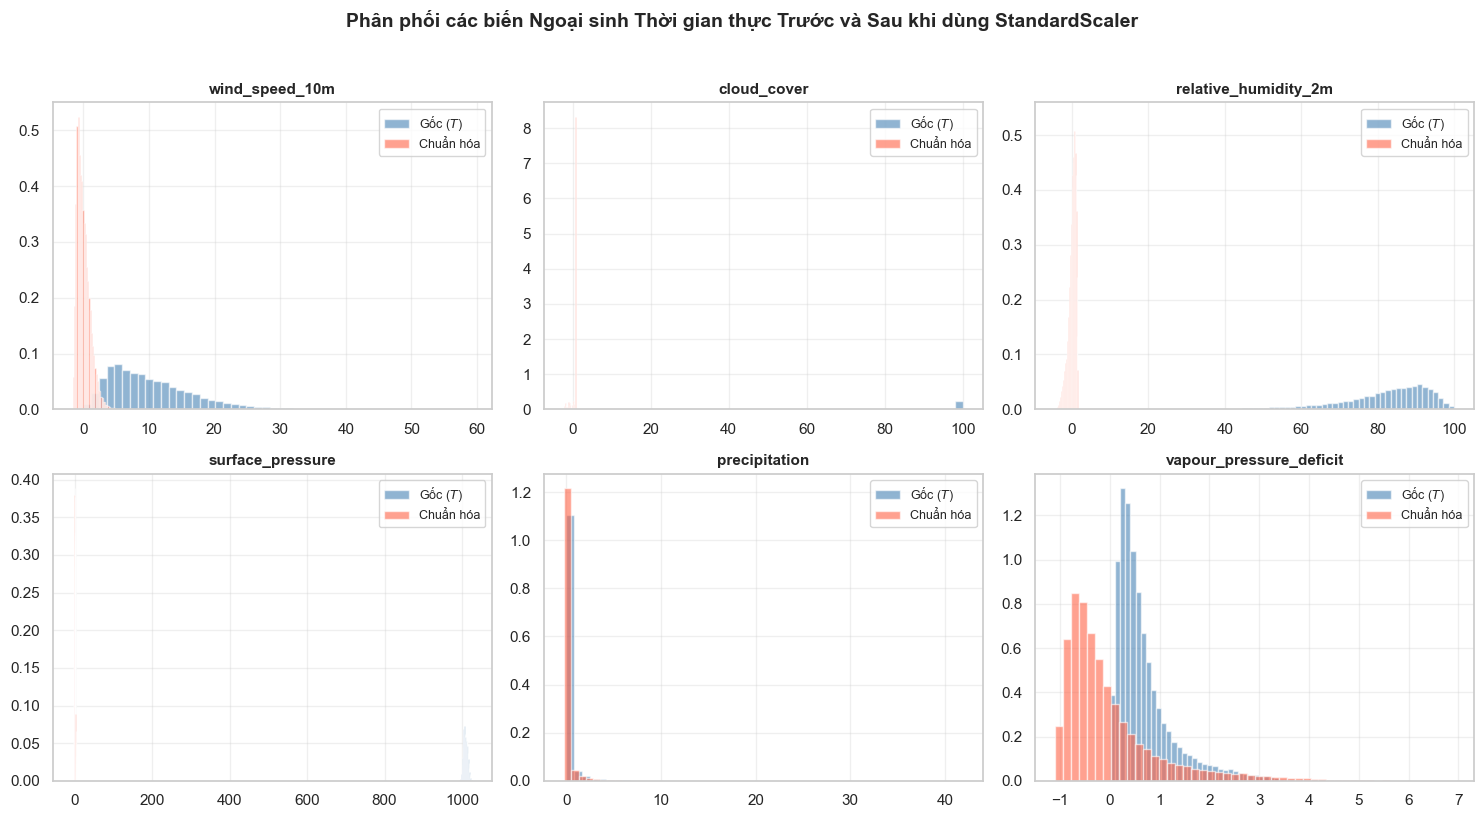

In [34]:
import matplotlib.pyplot as plt

# ==============================================================================
# TRỰC QUAN HÓA: So sánh phân phối Trước và Sau chuẩn hóa (Biến Ngoại sinh Thời gian thực)
# ==============================================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Duyệt qua danh sách 6 biến ngoại sinh gốc (exogenous_cols thay vì lagged_exo_cols)
for i, col in enumerate(exogenous_cols):
    ax = axes[i//3][i%3]
    
    # Vẽ phân phối TRƯỚC khi chuẩn hóa (Dữ liệu gốc thời gian thực)
    ax.hist(X_train_exo[:, i], bins=50, alpha=0.6,
            color='steelblue', label='Gốc ($T$)', density=True)
    
    # Vẽ phân phối SAU khi chuẩn hóa (Đã ép về Mean=0, Std=1)
    ax.hist(X_train_scaled[:, i], bins=50, alpha=0.6,
            color='tomato', label='Chuẩn hóa', density=True)
    
    # Định dạng tiêu đề cho từng ô đồ thị nhỏ
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Phân phối các biến Ngoại sinh Thời gian thực Trước và Sau khi dùng StandardScaler',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4.2 Tính ma trận hiệp phương sai

Ma trận hiệp phương sai S được tính theo công thức:
$$S = \frac{1}{N} \sum_{i=1}^{N} (x_i - \mu)(x_i - \mu)^T$$

=== MA TRẬN HIỆP PHƯƠNG SAI (BIẾN NGOẠI SINH THỜI GIAN THỰC) ===
                         wind_speed_10m  cloud_cover  relative_humidity_2m  \
wind_speed_10m                    1.000        0.031                -0.247   
cloud_cover                       0.031        1.000                 0.059   
relative_humidity_2m             -0.247        0.059                 1.000   
surface_pressure                  0.167        0.003                 0.293   
precipitation                     0.194        0.158                 0.135   
vapour_pressure_deficit           0.156       -0.056                -0.959   

                         surface_pressure  precipitation  \
wind_speed_10m                      0.167          0.194   
cloud_cover                         0.003          0.158   
relative_humidity_2m                0.293          0.135   
surface_pressure                    1.000          0.012   
precipitation                       0.012          1.000   
vapour_pressure_deficit     

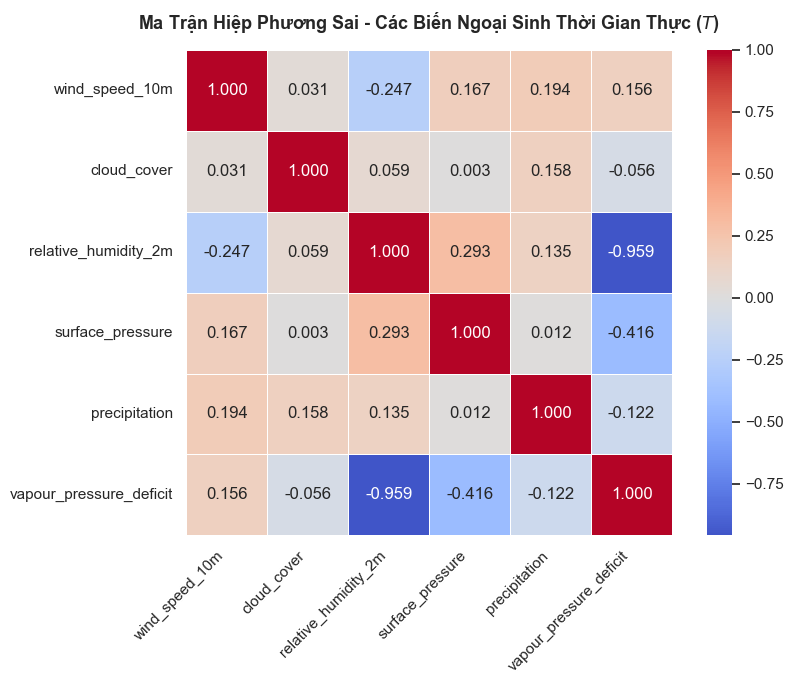

In [35]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ==============================================================================
# 3.2 Tính ma trận hiệp phương sai (Covariance Matrix)
# Dữ liệu đầu vào: X_train_scaled (Biến Ngoại sinh Thời gian thực tại thời điểm T)
# ==============================================================================

# Tính ma trận hiệp phương sai từ mảng đã chuẩn hóa ở bước 3.1
cov_matrix = np.cov(X_train_scaled.T)

# Sử dụng trực tiếp danh sách tên biến gốc làm nhãn (không cần replace đuôi lag)
cov_df = pd.DataFrame(cov_matrix, index=exogenous_cols, columns=exogenous_cols)

print("=== MA TRẬN HIỆP PHƯƠNG SAI (BIẾN NGOẠI SINH THỜI GIAN THỰC) ===")
print(cov_df.round(3))

# Trực quan hóa bằng Heatmap
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cov_df,
            annot=True,
            fmt='.3f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            ax=ax)

# Xoay nhãn trục X và trục Y để biểu đồ gọn gàng, không bị đè chữ
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

ax.set_title('Ma Trận Hiệp Phương Sai - Các Biến Ngoại Sinh Thời Gian Thực ($T$)', 
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### 4.3 Phân tích giá trị riêng (Explained Variance)

Tỉ lệ thông tin được giữ lại khi chọn K thành phần chính được tính theo công thức:
$$r_K = \frac{\sum_{i=1}^{K} \lambda_i}{\sum_{j=1}^{D} \lambda_j}$$

=== PHÂN TÍCH GIÁ TRỊ RIÊNG (BIẾN NGOẠI SINH THỜI GIAN THỰC) ===

PC       Giá trị riêng  Explained Var (%)  Tích lũy (%)
-------------------------------------------------------
PC1             2.2295             37.16%        37.16%
PC2             1.2943             21.57%        58.73%
PC3             1.0707             17.84%        76.57%
PC4             0.8470             14.12%        90.69%
PC5             0.5286              8.81%        99.50%
PC6             0.0300              0.50%       100.00%


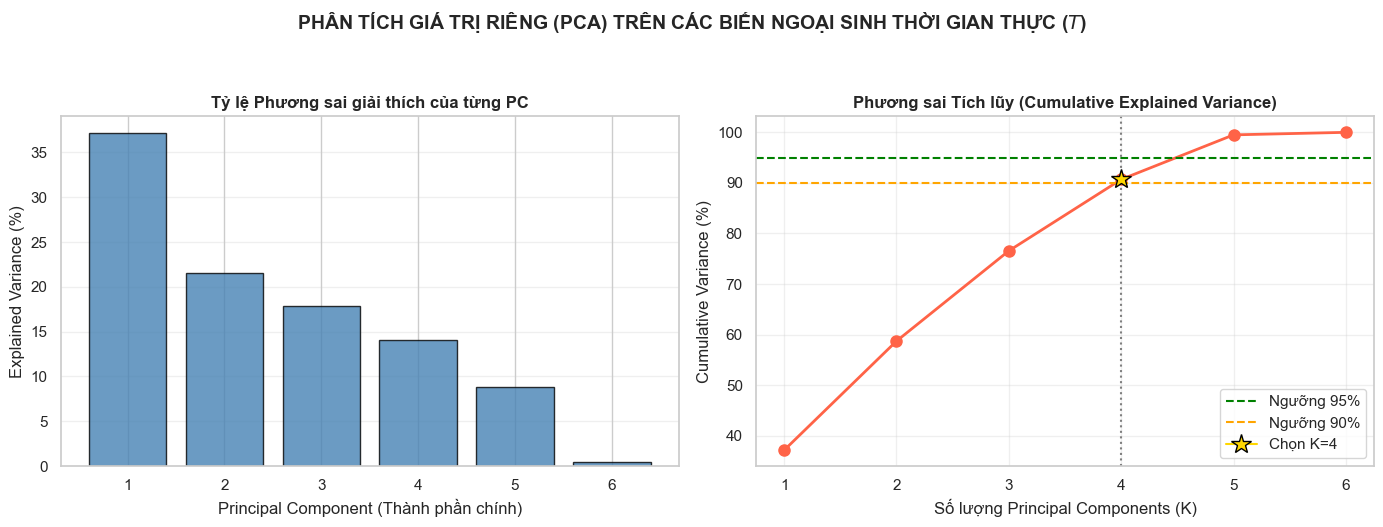

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ==============================================================================
# 3.3 Phân tích giá trị riêng (Explained Variance)
# Dữ liệu đầu vào: X_train_scaled (Biến Ngoại sinh Thời gian thực tại thời điểm T)
# ==============================================================================
pca_full = PCA()
pca_full.fit(X_train_scaled)

eigenvalues   = pca_full.explained_variance_
explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

print("=== PHÂN TÍCH GIÁ TRỊ RIÊNG (BIẾN NGOẠI SINH THỜI GIAN THỰC) ===")
print(f"\n{'PC':<6} {'Giá trị riêng':>15} {'Explained Var (%)':>18} {'Tích lũy (%)':>13}")
print("-" * 55)
for i, (ev, exp, cum) in enumerate(zip(eigenvalues, explained_var, cumulative_var)):
    print(f"PC{i+1:<4} {ev:>15.4f} {exp*100:>17.2f}% {cum*100:>12.2f}%")

# Khởi tạo khung bản vẽ
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Đồ thị 1: Tỷ lệ phương sai giải thích của từng PC cá lẻ
axes[0].bar(range(1, len(explained_var)+1), explained_var*100,
            color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_title('Tỷ lệ Phương sai giải thích của từng PC', fontweight='bold')
axes[0].set_xlabel('Principal Component (Thành phần chính)')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_xticks(range(1, len(explained_var)+1))
axes[0].grid(axis='y', alpha=0.3)

# Đồ thị 2: Phương sai tích lũy (Scree Plot)
axes[1].plot(range(1, len(cumulative_var)+1), cumulative_var*100,
             marker='o', color='tomato', linewidth=2, markersize=8)
axes[1].axhline(y=95, color='green', linestyle='--', label='Ngưỡng 95%')
axes[1].axhline(y=90, color='orange', linestyle='--', label='Ngưỡng 90%')

# Tự động định vị điểm cắt K tối ưu vượt ngưỡng 90% phương sai thông tin
target_threshold = 0.90
target_pc = np.argmax(cumulative_var >= target_threshold) + 1 
axes[1].axvline(x=target_pc, color='gray', linestyle=':', linewidth=1.5)
# Đánh dấu điểm K bằng ngôi sao vàng nổi bật
axes[1].plot(target_pc, cumulative_var[target_pc-1]*100, 
             marker='*', color='gold', markersize=15, markeredgecolor='black', label=f'Chọn K={target_pc}')

axes[1].set_title('Phương sai Tích lũy (Cumulative Explained Variance)', fontweight='bold')
axes[1].set_xlabel('Số lượng Principal Components (K)')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].set_xticks(range(1, len(cumulative_var)+1))
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.suptitle('PHÂN TÍCH GIÁ TRỊ RIÊNG (PCA) TRÊN CÁC BIẾN NGOẠI SINH THỜI GIAN THỰC ($T$)', 
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

### 4.4 Phân tích Loading Matrix

Loading Matrix thể hiện mức độ đóng góp (tải trọng) của từng biến gốc vào từng thành phần chính, giúp diễn giải ý nghĩa vật lý của từng PC.

=== LOADING MATRIX (MỨC ĐỘ ĐÓNG GÓP CỦA CÁC BIẾN NGOẠI SINH THỜI GIAN THỰC) ===
                           PC1    PC2    PC3    PC4    PC5    PC6
wind_speed_10m           0.211  0.767 -0.423  0.009  0.434  0.009
cloud_cover             -0.111  0.409  0.648  0.632  0.021  0.000
relative_humidity_2m    -0.954 -0.121  0.099 -0.103  0.203  0.120
surface_pressure        -0.530  0.284 -0.580  0.338 -0.433  0.015
precipitation           -0.188  0.664  0.354 -0.566 -0.279 -0.003
vapour_pressure_deficit  0.973  0.045  0.015  0.043 -0.183  0.123


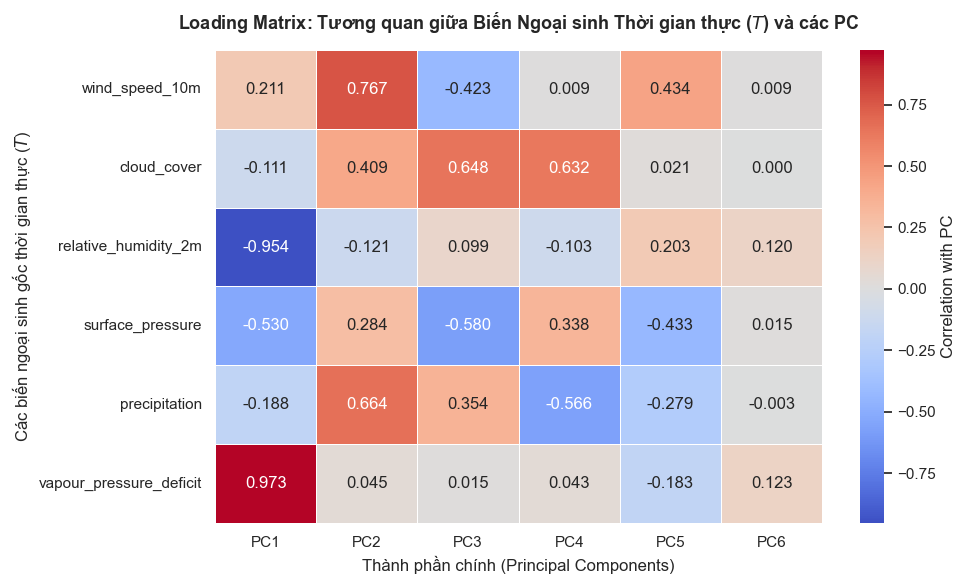

In [37]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ==============================================================================
# 3.4 Phân tích Loading Matrix (Hệ số tải đặc trưng Thời gian thực)
# ==============================================================================

# Lấy ma trận trọng số (Loadings) từ mô hình PCA đã fit
loadings = pca_full.components_.T * np.sqrt(pca_full.explained_variance_)

# Khởi tạo DataFrame với index là danh sách biến ngoại sinh gốc thời gian thực (exogenous_cols)
loading_df = pd.DataFrame(loadings, 
                          index=exogenous_cols, 
                          columns=[f'PC{i+1}' for i in range(pca_full.n_components_)])

print("=== LOADING MATRIX (MỨC ĐỘ ĐÓNG GÓP CỦA CÁC BIẾN NGOẠI SINH THỜI GIAN THỰC) ===")
print(loading_df.round(3))

# Trực quan hóa bằng Heatmap
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(loading_df, 
            annot=True, 
            cmap='coolwarm', 
            center=0, 
            fmt='.3f',
            linewidths=0.5,
            cbar_kws={'label': 'Correlation with PC'})

# Cấu hình tiêu đề đồ thị theo đúng bản chất dữ liệu mới
ax.set_title('Loading Matrix: Tương quan giữa Biến Ngoại sinh Thời gian thực ($T$) và các PC', 
             fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Các biến ngoại sinh gốc thời gian thực ($T$)')
plt.xlabel('Thành phần chính (Principal Components)')
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### 4.5 Lựa chọn số chiều K = 5 và Transform dữ liệu

Dựa trên kết quả phân tích Explained Variance, nhóm chọn **K = 5** thành phần chính:
- PC1–PC5 giữ lại **99.50%** tổng phương sai
- PC6 chỉ đóng góp **0.50%** → loại bỏ không đáng kể về mặt thông tin

In [38]:
import os
import pickle
import pandas as pd
from sklearn.decomposition import PCA

# ==============================================================================
# 3.5 Lựa chọn K = 5 và Transform dữ liệu thời gian thực
# w là vector riêng ứng với 5 giá trị riêng lớn nhất 
# (Theo tài liệu bài giảng Chương 7 - PCA)
# Dữ liệu đầu vào: X_train_scaled (Ngoại sinh thời gian thực tại thời điểm T)
# ==============================================================================
n_components = 5
pca_final = PCA(n_components=n_components)

# Thực hiện fit và transform trên không gian biến ngoại sinh đồng thì (Real-time)
X_train_pca = pca_final.fit_transform(X_train_scaled)

print(f"=== KẾT QUẢ PCA VỚI K = {n_components} (BIẾN THỜI GIAN THỰC) ===")
print(f"✓ Variance được giữ lại (Tổng tích lũy): {pca_final.explained_variance_ratio_.sum()*100:.2f}%")
print(f"✓ Số chiều ban đầu (Biến ngoại sinh gốc): {X_train_scaled.shape[1]}")
print(f"✓ Số chiều sau PCA (Thành phần chính): {X_train_pca.shape[1]}")
print(f"✓ X_train_pca shape: {X_train_pca.shape}")

# Lưu trữ ma trận xoay PCA phục vụ cho file test cuốn chiếu sau này
os.makedirs('saved_models', exist_ok=True)
with open('saved_models/pca.pkl', 'wb') as f:
    pickle.dump(pca_final, f)
print("✓ Đã lưu mô hình PCA thời gian thực vào 'saved_models/pca.pkl'")

# ==============================================================================
# TẠO DATAFRAME PCA CHO TẬP TRAIN (BẢN THỜI GIAN THỰC)
# ==============================================================================
pca_cols = [f'PC{i+1}' for i in range(n_components)]

train_pca_df = pd.DataFrame(X_train_pca, columns=pca_cols)

# Chèn lại cột thời gian và cột Target (Nhiệt độ thực tế tại T) từ train_df vào
# Lưu ý: Vì không dùng dịch trễ ngoại sinh, train_pca_df sẽ khớp thời gian hoàn toàn với train_df
train_pca_df.insert(0, 'time', train_df['time'].values)
train_pca_df['temperature_2m'] = train_df['temperature_2m'].values

print("\n📸 Train PCA DataFrame (5 dòng đầu):")
print(train_pca_df.head())

=== KẾT QUẢ PCA VỚI K = 5 (BIẾN THỜI GIAN THỰC) ===
✓ Variance được giữ lại (Tổng tích lũy): 99.50%
✓ Số chiều ban đầu (Biến ngoại sinh gốc): 6
✓ Số chiều sau PCA (Thành phần chính): 5
✓ X_train_pca shape: (42405, 5)
✓ Đã lưu mô hình PCA thời gian thực vào 'saved_models/pca.pkl'

📸 Train PCA DataFrame (5 dòng đầu):
                 time       PC1       PC2       PC3       PC4       PC5  \
0 2021-01-08 00:00:00 -1.325041  0.420644 -0.073519  0.802707 -0.338991   
1 2021-01-08 01:00:00 -1.364276  0.655012 -0.128110  0.716281 -0.119352   
2 2021-01-08 02:00:00 -1.636837  1.021646  0.315497  0.104926 -0.467793   
3 2021-01-08 03:00:00 -1.493092  1.127421  0.091812  0.252808 -0.081010   
4 2021-01-08 04:00:00 -1.238768  1.244822 -0.060918  0.356644 -0.048457   

   temperature_2m  
0           21.20  
1           21.05  
2           21.10  
3           21.30  
4           21.55  


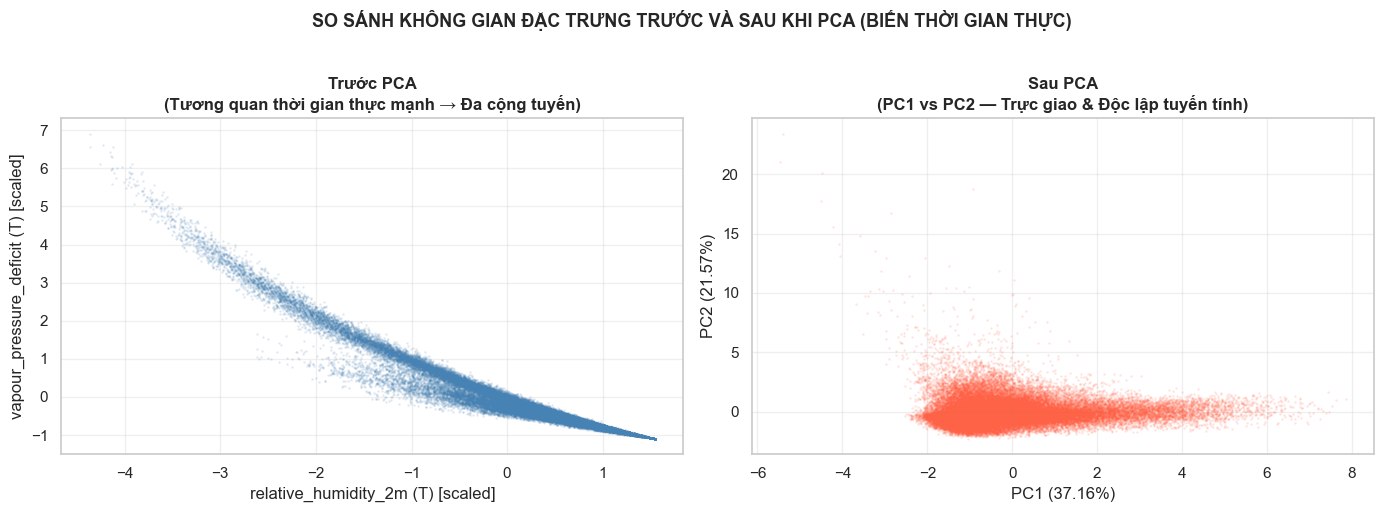

=== SO SÁNH TRƯỚC VÀ SAU PCA ===
Trước PCA: 6 chiều đặc trưng ngoại sinh gốc (T)
Sau PCA:   5 chiều thành phần chính (PC)
Variance giữ lại: 99.50%
Variance mất đi:  0.50%


In [39]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# TRỰC QUAN HÓA: So sánh không gian đặc trưng Trước và Sau PCA (Thời gian thực)
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tự động tìm vị trí index của 2 biến tương quan mạnh trong danh sách gốc (exogenous_cols)
idx_humidity = exogenous_cols.index('relative_humidity_2m')
idx_vpd = exogenous_cols.index('vapour_pressure_deficit')

# ------------------------------------------------------------------------------
# Đồ thị 1: Trước PCA — Cặp biến ngoại sinh thời gian thực có tương quan cao nhất
# ------------------------------------------------------------------------------
axes[0].scatter(X_train_scaled[:, idx_humidity], X_train_scaled[:, idx_vpd],
                alpha=0.1, s=1, color='steelblue')
axes[0].set_xlabel('relative_humidity_2m (T) [scaled]')
axes[0].set_ylabel('vapour_pressure_deficit (T) [scaled]')
axes[0].set_title('Trước PCA\n(Tương quan thời gian thực mạnh → Đa cộng tuyến)', fontweight='bold')
axes[0].grid(True, alpha=0.3)

# ------------------------------------------------------------------------------
# Đồ thị 2: Sau PCA — PC1 vs PC2 hoàn toàn vuông góc và độc lập tuyến tính
# ------------------------------------------------------------------------------
axes[1].scatter(X_train_pca[:, 0], X_train_pca[:, 1],
                alpha=0.1, s=1, color='tomato')
axes[1].set_xlabel(f'PC1 ({pca_final.explained_variance_ratio_[0]*100:.2f}%)')
axes[1].set_ylabel(f'PC2 ({pca_final.explained_variance_ratio_[1]*100:.2f}%)')
axes[1].set_title('Sau PCA\n(PC1 vs PC2 — Trực giao & Độc lập tuyến tính)', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.suptitle('SO SÁNH KHÔNG GIAN ĐẶC TRƯNG TRƯỚC VÀ SAU KHI PCA (BIẾN THỜI GIAN THỰC)', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("=== SO SÁNH TRƯỚC VÀ SAU PCA ===")
print(f"Trước PCA: {X_train_scaled.shape[1]} chiều đặc trưng ngoại sinh gốc (T)")
print(f"Sau PCA:   {X_train_pca.shape[1]} chiều thành phần chính (PC)")
print(f"Variance giữ lại: {pca_final.explained_variance_ratio_.sum()*100:.2f}%")
print(f"Variance mất đi:  {(1-pca_final.explained_variance_ratio_.sum())*100:.2f}%")

---
## 4. Trích xuất đặc trưng thời gian (Sin/Cos Encoding)

Dựa trên kết quả phân tích EDA (seasonal decompose và ACF/PACF), dữ liệu nhiệt độ Đà Nẵng có **2 chu kỳ rõ ràng**:
- **Chu kỳ ngày (24 giờ)**: nhiệt độ thấp nhất ~5-6h sáng, cao nhất ~12-13h trưa
- **Chu kỳ năm (12 tháng)**: mùa hè nóng (tháng 6-8), mùa đông mát (tháng 12-1)

Sử dụng biến đổi sin/cos để mã hóa tính tuần hoàn, đảm bảo giờ 23 và giờ 0 được nhận diện là gần nhau.

[*] Đang thực hiện Time Encoding cho Giờ trong ngày...
=== TIME ENCODING: GIỜ TRONG NGÀY (BẢNG PCA THỜI GIAN THỰC) ===
                  time  hour      sin_hour      cos_hour
0  2021-01-08 00:00:00     0  0.000000e+00  1.000000e+00
1  2021-01-08 01:00:00     1  2.588190e-01  9.659258e-01
2  2021-01-08 02:00:00     2  5.000000e-01  8.660254e-01
3  2021-01-08 03:00:00     3  7.071068e-01  7.071068e-01
4  2021-01-08 04:00:00     4  8.660254e-01  5.000000e-01
5  2021-01-08 05:00:00     5  9.659258e-01  2.588190e-01
6  2021-01-08 06:00:00     6  1.000000e+00  6.123234e-17
7  2021-01-08 07:00:00     7  9.659258e-01 -2.588190e-01
8  2021-01-08 08:00:00     8  8.660254e-01 -5.000000e-01
9  2021-01-08 09:00:00     9  7.071068e-01 -7.071068e-01
10 2021-01-08 10:00:00    10  5.000000e-01 -8.660254e-01
11 2021-01-08 11:00:00    11  2.588190e-01 -9.659258e-01
12 2021-01-08 12:00:00    12  1.224647e-16 -1.000000e+00
13 2021-01-08 13:00:00    13 -2.588190e-01 -9.659258e-01
14 2021-01-08 14:00:00    

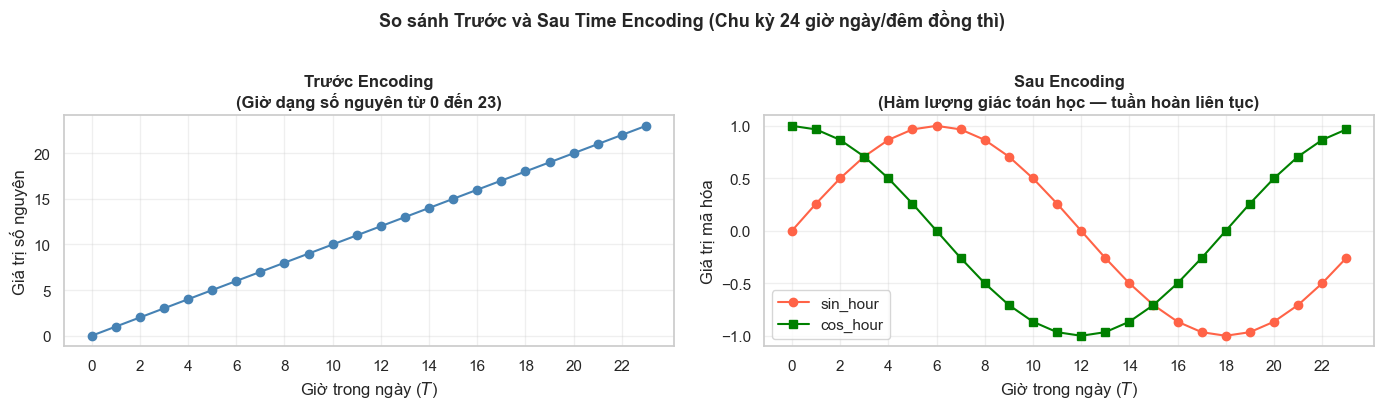

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==============================================================================
# 4.1 Sin/Cos encoding cho giờ trong ngày (chu kỳ 24h)
# Áp dụng trực tiếp vào train_pca_df để chuẩn bị bộ đặc trưng cho XGBoost
# Chiến lược: Đồng bộ với mốc thời gian thực T của biến ngoại sinh
# ==============================================================================
print("[*] Đang thực hiện Time Encoding cho Giờ trong ngày...")

# Trích xuất giờ từ cột 'time' (Thời gian thực tại T)
train_pca_df['hour']     = train_pca_df['time'].dt.hour
train_pca_df['sin_hour'] = np.sin(2 * np.pi * train_pca_df['hour'] / 24)
train_pca_df['cos_hour'] = np.cos(2 * np.pi * train_pca_df['hour'] / 24)

print("=== TIME ENCODING: GIỜ TRONG NGÀY (BẢNG PCA THỜI GIAN THỰC) ===")
print(train_pca_df[['time', 'hour', 'sin_hour', 'cos_hour']].head(24).to_string())

# ==============================================================================
# TRỰC QUAN HÓA TRƯỚC VÀ SAU ENCODING GIỜ
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

hours = range(24)
# Đồ thị 1: Trước Encoding
axes[0].plot(hours, list(hours), marker='o', color='steelblue', linewidth=1.5)
axes[0].set_title('Trước Encoding\n(Giờ dạng số nguyên từ 0 đến 23)', fontweight='bold')
axes[0].set_xlabel('Giờ trong ngày ($T$)')
axes[0].set_ylabel('Giá trị số nguyên')
axes[0].set_xticks(range(0, 24, 2))
axes[0].grid(True, alpha=0.3)

# Đồ thị 2: Sau Encoding (Tuần hoàn Sin/Cos)
sin_vals = np.sin(2 * np.pi * np.array(list(hours)) / 24)
cos_vals = np.cos(2 * np.pi * np.array(list(hours)) / 24)
axes[1].plot(hours, sin_vals, marker='o', color='tomato',  linewidth=1.5, label='sin_hour')
axes[1].plot(hours, cos_vals, marker='s', color='green',   linewidth=1.5, label='cos_hour')
axes[1].set_title('Sau Encoding\n(Hàm lượng giác toán học — tuần hoàn liên tục)', fontweight='bold')
axes[1].set_xlabel('Giờ trong ngày ($T$)')
axes[1].set_ylabel('Giá trị mã hóa')
axes[1].set_xticks(range(0, 24, 2))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('So sánh Trước và Sau Time Encoding (Chu kỳ 24 giờ ngày/đêm đồng thì)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

[*] Đang thực hiện Time Encoding cho Tháng trong năm...
=== TIME ENCODING: THÁNG TRONG NĂM (BẢNG PCA THỜI GIAN THỰC) ===
       month     sin_month     cos_month
month                                   
1          1  5.000000e-01  8.660254e-01
2          2  8.660254e-01  5.000000e-01
3          3  1.000000e+00  6.123234e-17
4          4  8.660254e-01 -5.000000e-01
5          5  5.000000e-01 -8.660254e-01
6          6  1.224647e-16 -1.000000e+00
7          7 -5.000000e-01 -8.660254e-01
8          8 -8.660254e-01 -5.000000e-01
9          9 -1.000000e+00 -1.836970e-16
10        10 -8.660254e-01  5.000000e-01
11        11 -5.000000e-01  8.660254e-01
12        12 -2.449294e-16  1.000000e+00


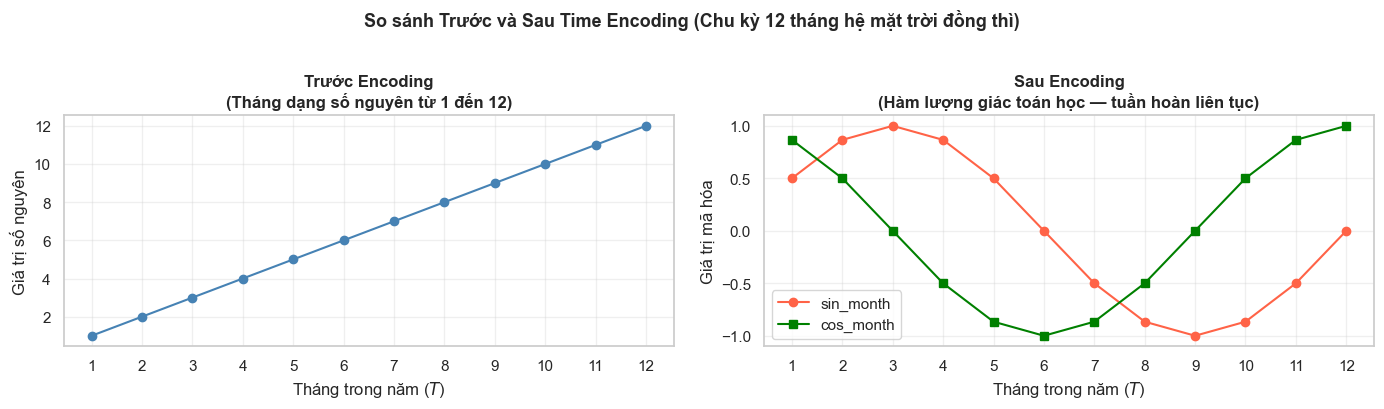

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==============================================================================
# 4.2 Sin/Cos encoding cho tháng trong năm (chu kỳ 12 tháng)
# Áp dụng trực tiếp vào train_pca_df để chuẩn bị bộ đặc trưng cho XGBoost
# Chiến lược: Đồng bộ với mốc thời gian thực T của biến ngoại sinh
# ==============================================================================
print("[*] Đang thực hiện Time Encoding cho Tháng trong năm...")

# Trích xuất tháng từ cột 'time' (Thời gian thực tại T)
train_pca_df['month']     = train_pca_df['time'].dt.month
train_pca_df['sin_month'] = np.sin(2 * np.pi * train_pca_df['month'] / 12)
train_pca_df['cos_month'] = np.cos(2 * np.pi * train_pca_df['month'] / 12)

print("=== TIME ENCODING: THÁNG TRONG NĂM (BẢNG PCA THỜI GIAN THỰC) ===")
# Lấy mẫu đại diện của 12 tháng để in ra kiểm tra
monthly_sample = train_pca_df.groupby('month')[['month', 'sin_month', 'cos_month']].first()
print(monthly_sample.to_string())

# ==============================================================================
# TRỰC QUAN HÓA TRƯỚC VÀ SAU ENCODING THÁNG
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

months = range(1, 13)
# Đồ thị 1: Trước Encoding
axes[0].plot(months, list(months), marker='o', color='steelblue', linewidth=1.5)
axes[0].set_title('Trước Encoding\n(Tháng dạng số nguyên từ 1 đến 12)', fontweight='bold')
axes[0].set_xlabel('Tháng trong năm ($T$)')
axes[0].set_ylabel('Giá trị số nguyên')
axes[0].set_xticks(range(1, 13))
axes[0].grid(True, alpha=0.3)

# Đồ thị 2: Sau Encoding (Tuần hoàn Sin/Cos)
sin_m = np.sin(2 * np.pi * np.array(list(months)) / 12)
cos_m = np.cos(2 * np.pi * np.array(list(months)) / 12)
axes[1].plot(months, sin_m, marker='o', color='tomato', linewidth=1.5, label='sin_month')
axes[1].plot(months, cos_m, marker='s', color='green',  linewidth=1.5, label='cos_month')
axes[1].set_title('Sau Encoding\n(Hàm lượng giác toán học — tuần hoàn liên tục)', fontweight='bold')
axes[1].set_xlabel('Tháng trong năm ($T$)')
axes[1].set_ylabel('Giá trị mã hóa')
axes[1].set_xticks(range(1, 13))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('So sánh Trước và Sau Time Encoding (Chu kỳ 12 tháng hệ mặt trời đồng thì)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [42]:
# ==============================================================================
# 4.3 Kiểm tra cấu trúc bảng PCA kết hợp Time Encoding
# (Bỏ phần gán thủ công và tập Test vì đã xử lý trực tiếp ở bước trước)
# ==============================================================================

print("=== CẤU TRÚC BẢNG TRAIN PCA DATAFRAME HIỆN TẠI ===")
print(f"Tổng số cột: {len(train_pca_df.columns)}")
print(f"Danh sách các cột: {train_pca_df.columns.tolist()}")

print("\nXem thử 5 dòng dữ liệu đầu tiên:")
print(train_pca_df[['time', 'PC1', 'PC2', 'sin_hour', 'cos_hour', 'sin_month', 'cos_month', 'temperature_2m']].head())

=== CẤU TRÚC BẢNG TRAIN PCA DATAFRAME HIỆN TẠI ===
Tổng số cột: 13
Danh sách các cột: ['time', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'temperature_2m', 'hour', 'sin_hour', 'cos_hour', 'month', 'sin_month', 'cos_month']

Xem thử 5 dòng dữ liệu đầu tiên:
                 time       PC1       PC2  sin_hour  cos_hour  sin_month  \
0 2021-01-08 00:00:00 -1.325041  0.420644  0.000000  1.000000        0.5   
1 2021-01-08 01:00:00 -1.364276  0.655012  0.258819  0.965926        0.5   
2 2021-01-08 02:00:00 -1.636837  1.021646  0.500000  0.866025        0.5   
3 2021-01-08 03:00:00 -1.493092  1.127421  0.707107  0.707107        0.5   
4 2021-01-08 04:00:00 -1.238768  1.244822  0.866025  0.500000        0.5   

   cos_month  temperature_2m  
0   0.866025           21.20  
1   0.866025           21.05  
2   0.866025           21.10  
3   0.866025           21.30  
4   0.866025           21.55  


---
## 5. Tổng hợp bộ đặc trưng cuối cùng

In [43]:
# ==============================================================================
# 5. Tổng hợp bộ đặc trưng cuối cùng (PCA + TIME ENCODING + TARGET LAGS)
# ==============================================================================

# BƯỚC QUYẾT ĐỊNH: Kéo các cột Target Lag từ train_df gốc sang train_pca_df
# (train_df gốc là file đã dropna ở phần tạo Lag ban đầu)
lag_hours = [1, 2, 3, 12, 24, 72, 168]
for lag in lag_hours:
    lag_col_name = f'temp_lag_{lag}'
    train_pca_df[lag_col_name] = train_df[lag_col_name].values

# Lấy danh sách các cột đặc trưng đầu vào (loại bỏ cột định danh và cột nhãn)
# Loại bỏ thêm cả cột trung gian 'hour' và 'month' nếu có
feature_cols_final = [col for col in train_pca_df.columns 
                      if col not in ['time', 'temperature_2m', 'hour', 'month']]

print("=" * 65)
print("TỔNG HỢP BỘ ĐẶC TRƯNG CUỐI CÙNG CHO XGBOOST (PRODUCTION-READY)")
print("=" * 65)
print(f"📍 Biến mục tiêu (Target): temperature_2m")
print(f"📍 Tổng số features đầu vào: {len(feature_cols_final)} biến")
print("\nChi tiết danh sách các đặc trưng:")
for i, col in enumerate(feature_cols_final, 1):
    print(f"  {i:2d}. {col}")

print("\n" + "-" * 75)
print(f"{'Tập dữ liệu':<15} {'Số mẫu (Rows)':>15} {'Số đặc trưng (Features)':>22} {'Khoảng thời gian'}")
print("-" * 75)
print(f"{'Train (Huấn luyện)':<15} {len(train_pca_df):>15} {len(feature_cols_final):>22} "
      f"{train_pca_df['time'].min().date()} → {train_pca_df['time'].max().date()}")
print("-" * 75)

print("\n📸 Trực quan 5 dòng đầu tiên của Ma trận huấn luyện cuối cùng:")
print(train_pca_df[['time'] + feature_cols_final + ['temperature_2m']].head())

TỔNG HỢP BỘ ĐẶC TRƯNG CUỐI CÙNG CHO XGBOOST (PRODUCTION-READY)
📍 Biến mục tiêu (Target): temperature_2m
📍 Tổng số features đầu vào: 16 biến

Chi tiết danh sách các đặc trưng:
   1. PC1
   2. PC2
   3. PC3
   4. PC4
   5. PC5
   6. sin_hour
   7. cos_hour
   8. sin_month
   9. cos_month
  10. temp_lag_1
  11. temp_lag_2
  12. temp_lag_3
  13. temp_lag_12
  14. temp_lag_24
  15. temp_lag_72
  16. temp_lag_168

---------------------------------------------------------------------------
Tập dữ liệu       Số mẫu (Rows) Số đặc trưng (Features) Khoảng thời gian
---------------------------------------------------------------------------
Train (Huấn luyện)           42405                     16 2021-01-08 → 2025-11-09
---------------------------------------------------------------------------

📸 Trực quan 5 dòng đầu tiên của Ma trận huấn luyện cuối cùng:
                 time       PC1       PC2       PC3       PC4       PC5  \
0 2021-01-08 00:00:00 -1.325041  0.420644 -0.073519  0.802707 -0.33

In [44]:
import pandas as pd

# ==============================================================================
# CHUẨN BỊ 3 PHIÊN BẢN DATASET HUẤN LUYỆN ĐỂ ĐỐI CHIẾU HIỆU NĂNG
# Chiến lược: Sử dụng dữ liệu NGOẠI SINH THỜI GIAN THỰC (Biết trước tương lai tại T)
# ==============================================================================

# 1. Khai báo danh sách 6 biến ngoại sinh gốc thời gian thực (Không dùng đuôi _lag_24)
exogenous_cols = [
    'wind_speed_10m', 'cloud_cover', 'relative_humidity_2m',
    'surface_pressure', 'precipitation', 'vapour_pressure_deficit'
]

lag_hours = [1, 2, 3, 12, 24, 72, 168]
time_cols = ['sin_hour', 'cos_hour', 'sin_month', 'cos_month']
lag_cols = [f'temp_lag_{l}' for l in lag_hours]

# ------------------------------------------------------------------------------
# Phiên bản DATASET 1: RAW 
# (Chỉ gồm 6 cột ngoại sinh gốc tại thời điểm T, không thêm gì khác)
# ------------------------------------------------------------------------------
X_train_raw = train_df[exogenous_cols].copy()
y_train_raw = train_df['temperature_2m'].copy()

# ------------------------------------------------------------------------------
# Phiên bản DATASET 2: FE_no_PCA 
# (Chuẩn hóa ngoại sinh tại T + Thêm Lag nhiệt độ/Time | Tổng = 6 + 4 + 7 = 17 biến)
# ------------------------------------------------------------------------------
# Tạo DataFrame từ mảng X_train_scaled (Đã được scale thời gian thực từ bước 3.1)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=exogenous_cols)

# Trích xuất các đặc trưng thời gian và đặc trưng trễ của nhiệt độ từ train_pca_df
X_train_lag_time = train_pca_df[time_cols + lag_cols].copy()

# Ráp trục ngang (axis=1) để tạo bộ dữ liệu 17 biến đồng thì
X_train_fe_no_pca = pd.concat([X_train_scaled_df, X_train_lag_time], axis=1)
y_train_fe_no_pca = train_df['temperature_2m'].copy()

# ------------------------------------------------------------------------------
# Phiên bản DATASET 3: FE_PCA 
# (Bộ đặc trưng tối ưu: 5 cấu phần PCA thời gian thực + 4 Time + 7 Lags = 16 biến)
# ------------------------------------------------------------------------------
pca_features = [f'PC{i+1}' for i in range(5)] + time_cols + lag_cols
X_train_fe_pca = train_pca_df[pca_features].copy()
y_train_fe_pca = train_pca_df['temperature_2m'].copy()

# ------------------------------------------------------------------------------
# IN KẾT QUẢ KIỂM TRA CẤU TRÚC
# ------------------------------------------------------------------------------
print("="*65)
print("KHỞI TẠO THÀNH CÔNG 3 PHIÊN BẢN DỮ LIỆU HUẤN LUYỆN THỜI GIAN THỰC:")
print("="*65)
print(f" ❖ Phiên bản RAW       : {X_train_raw.shape} -> Gồm 6 cột ngoại sinh gốc thời gian thực (T).")
print(f" ❖ Phiên bản FE_no_PCA : {X_train_fe_no_pca.shape} -> Gồm 17 cột (Scale T + Time T + Target Lags).")
print(f" ❖ Phiên bản FE_PCA    : {X_train_fe_pca.shape} -> Gồm 16 cột (5 PC Realtime + Time T + Target Lags).")
print("-"*65)
print(f" Kích thước nhãn mục tiêu (y_train): {y_train_raw.shape}")
print("="*65)

KHỞI TẠO THÀNH CÔNG 3 PHIÊN BẢN DỮ LIỆU HUẤN LUYỆN THỜI GIAN THỰC:
 ❖ Phiên bản RAW       : (42405, 6) -> Gồm 6 cột ngoại sinh gốc thời gian thực (T).
 ❖ Phiên bản FE_no_PCA : (42405, 17) -> Gồm 17 cột (Scale T + Time T + Target Lags).
 ❖ Phiên bản FE_PCA    : (42405, 16) -> Gồm 16 cột (5 PC Realtime + Time T + Target Lags).
-----------------------------------------------------------------
 Kích thước nhãn mục tiêu (y_train): (42405,)


# PHẦN 5: HUẤN LUYỆN MÔ HÌNH THỐNG KÊ & MACHINE LEARNING

TIME SERIES CV PIPELINE - CHIẾN LƯỢC NGOẠI SINH THỜI GIAN THỰC (REAL-TIME)
[1/5] Đang nạp dữ liệu nền tảng...
[2/5] Cấu hình cấu trúc 5-Fold Time Series Split...
[3/5] Bắt đầu quá trình huấn luyện song song đa chiến lược...

🚀 ĐANG XỬ LÝ FOLD 1/5 ----------------------------------------
  ✓ Đã xong chiến lược: RAW        (Tất cả mô hình)
  ✓ Đã xong chiến lược: FE_no_PCA  (Tất cả mô hình)
  ✓ Đã xong chiến lược: FE_PCA     (Tất cả mô hình)

🚀 ĐANG XỬ LÝ FOLD 2/5 ----------------------------------------
  ✓ Đã xong chiến lược: RAW        (Tất cả mô hình)
  ✓ Đã xong chiến lược: FE_no_PCA  (Tất cả mô hình)
  ✓ Đã xong chiến lược: FE_PCA     (Tất cả mô hình)

🚀 ĐANG XỬ LÝ FOLD 3/5 ----------------------------------------
  ✓ Đã xong chiến lược: RAW        (Tất cả mô hình)
  ✓ Đã xong chiến lược: FE_no_PCA  (Tất cả mô hình)
  ✓ Đã xong chiến lược: FE_PCA     (Tất cả mô hình)

🚀 ĐANG XỬ LÝ FOLD 4/5 ----------------------------------------
  ✓ Đã xong chiến lược: RAW        (Tất cả mô hình)


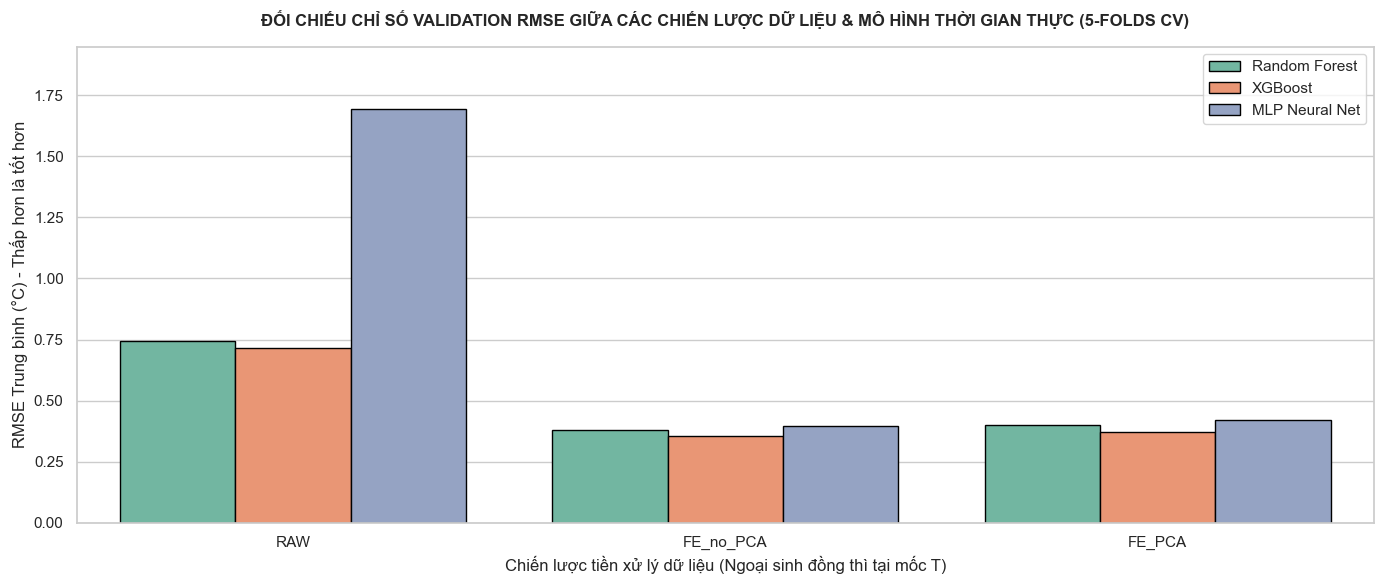

🎉 XỬ LÝ HOÀN TẤT! Toàn bộ mô hình và Metadata đã sẵn sàng cho pha Testing.


In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
import pickle
import os

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

print("="*85)
print("TIME SERIES CV PIPELINE - CHIẾN LƯỢC NGOẠI SINH THỜI GIAN THỰC (REAL-TIME)")
print("="*85)

# ==============================================================================
# 1. NẠP DỮ LIỆU GỐC NỀN TẢNG
# ==============================================================================
DATA_PATH = 'clean_data/clean_data_train.csv'
TARGET = 'temperature_2m'

print("[1/5] Đang nạp dữ liệu nền tảng...")
raw_df = pd.read_csv(DATA_PATH)
raw_df['time'] = pd.to_datetime(raw_df['time'])
raw_df = raw_df.sort_values('time').reset_index(drop=True)

# Khai báo các cột ngoại sinh vật lý gốc thời gian thực tại T
exogenous_cols = ['wind_speed_10m', 'cloud_cover', 'relative_humidity_2m', 
                  'surface_pressure', 'precipitation', 'vapour_pressure_deficit']

# ==============================================================================
# 2. THIẾT LẬP CROSS-VALIDATION ĐA CHIỀU
# ==============================================================================
print("[2/5] Cấu hình cấu trúc 5-Fold Time Series Split...")
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

strategies = ['RAW', 'FE_no_PCA', 'FE_PCA']
models_pool = ['Random Forest', 'XGBoost', 'MLP Neural Net']

# Khởi tạo bảng lưu trữ kết quả cho cả 9 cấu hình thử nghiệm
cv_tracking = {s: {m: {'val_rmse': [], 'val_mae': [], 'val_r2': []} for m in models_pool} for s in strategies}

# ==============================================================================
# 3. VÒNG LẶP ĐÁNH GIÁ CHÉO (CROSS-VALIDATION LOOP)
# ==============================================================================
print("[3/5] Bắt đầu quá trình huấn luyện song song đa chiến lược...")

for fold, (train_idx, val_idx) in enumerate(tscv.split(raw_df)):
    print(f"\n🚀 ĐANG XỬ LÝ FOLD {fold + 1}/{n_splits} " + "-"*40)
    
    fold_train_raw = raw_df.iloc[train_idx].copy()
    fold_val_raw = raw_df.iloc[val_idx].copy()
    
    # --------------------------------------------------------------------------
    # BƯỚC THỰC THI CHIẾN LƯỢC DỮ LIỆU TRÊN TỪNG FOLD (CHỐNG LEAKAGE TUYỆT ĐỐI)
    # --------------------------------------------------------------------------
    def build_features_inside_fold(df_input):
        df = df_input.copy()
        # 1. Mã hóa chu kỳ thời gian thực tại T
        df['hour'] = df['time'].dt.hour
        df['sin_hour'] = np.sin(2 * np.pi * df['hour'] / 24)
        df['cos_hour'] = np.cos(2 * np.pi * df['hour'] / 24)
        df['month'] = df['time'].dt.month
        df['sin_month'] = np.sin(2 * np.pi * df['month'] / 12)
        df['cos_month'] = np.cos(2 * np.pi * df['month'] / 12)
        
        # 2. Chỉ tạo biến trễ (Lag) cho biến mục tiêu Nhiệt độ
        for lag in [1, 2, 3, 12, 24, 72, 168]:
            df[f'temp_lag_{lag}'] = df[TARGET].shift(lag)
            
        df.dropna(inplace=True)
        return df

    fold_train_fe = build_features_inside_fold(fold_train_raw)
    fold_val_fe = build_features_inside_fold(fold_val_raw)
    
    # Định nghĩa lại các nhóm cột đặc trưng lượng giác và trễ nhiệt độ
    time_lag_cols = ['sin_hour', 'cos_hour', 'sin_month', 'cos_month'] + [f'temp_lag_{l}' for l in [1, 2, 3, 12, 24, 72, 168]]
    
    # Chuẩn hóa (Scaler) và áp dụng PCA cục bộ trực tiếp trên nhóm ngoại sinh thời gian thực
    scaler_fold = StandardScaler()
    X_train_exo_scaled = scaler_fold.fit_transform(fold_train_fe[exogenous_cols])
    X_val_exo_scaled = scaler_fold.transform(fold_val_fe[exogenous_cols])
    
    pca_fold = PCA(n_components=5)
    X_train_exo_pca = pca_fold.fit_transform(X_train_exo_scaled)
    X_val_exo_pca = pca_fold.transform(X_val_exo_scaled)
    
    # Đóng gói 3 phiên bản dữ liệu đầu vào thời gian thực cho Fold hiện tại
    datasets_dict = {
        'RAW': (
            fold_train_fe[exogenous_cols].values, 
            fold_val_fe[exogenous_cols].values
        ),
        'FE_no_PCA': (
            np.hstack([X_train_exo_scaled, fold_train_fe[time_lag_cols].values]), 
            np.hstack([X_val_exo_scaled, fold_val_fe[time_lag_cols].values])
        ),
        'FE_PCA': (
            np.hstack([X_train_exo_pca, fold_train_fe[time_lag_cols].values]), 
            np.hstack([X_val_exo_pca, fold_val_fe[time_lag_cols].values])
        )
    }
    
    y_tr = fold_train_fe[TARGET].values
    y_va = fold_val_fe[TARGET].values
    
    # --------------------------------------------------------------------------
    # VÒNG LẶP HUẤN LUYỆN MÔ HÌNH TRÊN CÁC DATASETS
    # --------------------------------------------------------------------------
    for strat in strategies:
        X_tr, X_va = datasets_dict[strat]
        
        models_dict = {
            'Random Forest': RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1),
            'XGBoost': xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1),
            'MLP Neural Net': MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu', solver='adam', max_iter=300, early_stopping=True, random_state=42)
        }
        
        for m_name, model in models_dict.items():
            model.fit(X_tr, y_tr)
            preds = model.predict(X_va)
            
            mae = mean_absolute_error(y_va, preds)
            rmse = np.sqrt(mean_squared_error(y_va, preds))
            r2 = r2_score(y_va, preds)
            
            cv_tracking[strat][m_name]['val_mae'].append(mae)
            cv_tracking[strat][m_name]['val_rmse'].append(rmse)
            cv_tracking[strat][m_name]['val_r2'].append(r2)
            
        print(f"  ✓ Đã xong chiến lược: {strat:<10} (Tất cả mô hình)")

# ==============================================================================
# 4. TỔNG HỢP CHỈ SỐ TRUNG BÌNH & XÁC ĐỊNH PHƯƠNG ÁN CHIẾN THẮNG
# ==============================================================================
print("\n[4/5] Tính toán kết quả trung bình qua 5 Folds...")

summary_rows = []
best_score = float('inf')
best_strategy = ""
best_model = ""

for strat in strategies:
    for m_name in models_pool:
        avg_mae = np.mean(cv_tracking[strat][m_name]['val_mae'])
        avg_rmse = np.mean(cv_tracking[strat][m_name]['val_rmse'])
        avg_r2 = np.mean(cv_tracking[strat][m_name]['val_r2'])
        
        summary_rows.append({
            'Chiến lược Data': strat,
            'Mô hình': m_name,
            'Val MAE (°C)': avg_mae,
            'Val RMSE (°C)': avg_rmse,
            'Val R2 Score': avg_r2
        })
        
        if avg_rmse < best_score:
            best_score = avg_rmse
            best_strategy = strat
            best_model = m_name

df_cv_summary = pd.DataFrame(summary_rows)
print("\n" + "="*80)
print("BẢNG TỔNG HỢP ĐÁNH GIÁ CHÉO (DỮ LIỆU NGOẠI SINH THỜI GIAN THỰC T):")
print("="*80)
print(df_cv_summary.to_string(index=False))
print("="*80)
print(f"🏆 CẶP BÀI TRÙNG XUẤT SẮC NHẤT: {best_model} + Chiến lược {best_strategy}")
print(f"📍 Chỉ số Validation RMSE tối ưu: {best_score:.4f} °C")
print("="*80)

# ==============================================================================
# 5. HUẤN LUYỆN LẠI PHƯƠNG ÁN XUẤT SẮC NHẤT TRÊN TOÀN BỘ DATA ĐỂ DEPLOY
# ==============================================================================
print(f"\n[5/5] Đang tái cấu trúc và huấn luyện lại cấu hình tối ưu trên toàn bộ dữ liệu...")

def build_final_features(df_input):
    df = df_input.copy()
    df['hour'] = df['time'].dt.hour
    df['sin_hour'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['cos_hour'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['month'] = df['time'].dt.month
    df['sin_month'] = np.sin(2 * np.pi * df['month'] / 12)
    df['cos_month'] = np.cos(2 * np.pi * df['month'] / 12)
    for lag in [1, 2, 3, 12, 24, 72, 168]: 
        df[f'temp_lag_{lag}'] = df[TARGET].shift(lag)
    df.dropna(inplace=True)
    return df

final_full_df = build_final_features(raw_df)

os.makedirs('saved_models', exist_ok=True)
scaler_prod = StandardScaler()
X_exo_scaled_full = scaler_prod.fit_transform(final_full_df[exogenous_cols])
joblib.dump(scaler_prod, 'saved_models/scaler.pkl')

# Đóng gói dữ liệu huấn luyện Production theo chiến lược chiến thắng
if best_strategy == 'FE_PCA':
    pca_prod = PCA(n_components=5)
    X_exo_pca_full = pca_prod.fit_transform(X_exo_scaled_full)
    with open('saved_models/pca.pkl', 'wb') as f:
        pickle.dump(pca_prod, f)
    X_final_prod = np.hstack([X_exo_pca_full, final_full_df[time_lag_cols].values])
elif best_strategy == 'FE_no_PCA':
    # Nếu chạy qua đây, file pca.pkl cũ rác trong quá khứ sẽ bị xóa bỏ một cách chủ động
    if os.path.exists('saved_models/pca.pkl'):
        os.remove('saved_models/pca.pkl')
    X_final_prod = np.hstack([X_exo_scaled_full, final_full_df[time_lag_cols].values])
else: # RAW
    if os.path.exists('saved_models/pca.pkl'):
        os.remove('saved_models/pca.pkl')
    X_final_prod = final_full_df[exogenous_cols].values

y_final_prod = final_full_df[TARGET].values

# Khởi tạo mô hình tốt nhất với siêu tham số Production toàn vẹn
if best_model == 'XGBoost':
    prod_model = xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)
elif best_model == 'Random Forest':
    prod_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
else:
    prod_model = MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu', solver='adam', max_iter=400, random_state=42)

prod_model.fit(X_final_prod, y_final_prod)
joblib.dump(prod_model, 'saved_models/best_production_model.pkl')

# TÍNH NĂNG QUYẾT ĐỊNH: Đóng gói Metadata để bàn giao hình dáng ma trận cho file Test
model_metadata = {
    'best_strategy': best_strategy,
    'expected_features': X_final_prod.shape[1]
}
with open('saved_models/model_metadata.pkl', 'wb') as f:
    pickle.dump(model_metadata, f)

print("💾 HỆ THỐNG ĐÃ LƯU BỘ BA PRODUCTION THỜI GIAN THỰC TRONG 'saved_models/':")
print("   -> Mô hình tốt nhất : 'best_production_model.pkl'")
print("   -> Bộ Scaler gốc    : 'scaler.pkl'")
print(f"   -> File Metadata    : 'model_metadata.pkl' (Ghi nhận {best_strategy} với {X_final_prod.shape[1]} đặc trưng)")
if best_strategy == 'FE_PCA':
    print("   -> Bộ nén PCA       : 'pca.pkl'")
print("="*85)

# ==============================================================================
# 6. TRỰC QUAN HÓA PHÂN TÍCH ĐA CHIỀU
# ==============================================================================
print("🎨 Đang kết xuất biểu đồ so sánh đa chiều...")
df_plot = df_cv_summary.copy()

plt.figure(figsize=(14, 6))
sns.barplot(data=df_plot, x='Chiến lược Data', y='Val RMSE (°C)', hue='Mô hình', palette='Set2', edgecolor='black')
plt.title('ĐỐI CHIẾU CHỈ SỐ VALIDATION RMSE GIỮA CÁC CHIẾN LƯỢC DỮ LIỆU & MÔ HÌNH THỜI GIAN THỰC (5-FOLDS CV)', fontsize=12, fontweight='bold', pad=15)
plt.ylabel('RMSE Trung bình (°C) - Thấp hơn là tốt hơn')
plt.xlabel('Chiến lược tiền xử lý dữ liệu (Ngoại sinh đồng thì tại mốc T)')
plt.ylim(0, df_plot['Val RMSE (°C)'].max() * 1.15)
plt.legend(loc='upper right', frameon=True)
plt.tight_layout()

plt.savefig('multi_strategy_cv_comparison.png', dpi=300)
plt.show()

print("🎉 XỬ LÝ HOÀN TẤT! Toàn bộ mô hình và Metadata đã sẵn sàng cho pha Testing.")